In [1]:
import json
import pandas as pd
from PIL import Image
import os

# Извлекаю аннотации из json-файла
with open('output/all_results.json', 'r', encoding='utf-8') as f:
    json_data = json.load(f)['results']


def parse_anns(ann):
    # В данных есть артефакты, поэтому через исключения
    try:
        ann_str = ann.replace('```json\n', '').replace('\n```', '')
        return json.loads(ann_str)
    except:
        return None

output_df_f = 'output/annotations.pkl'

# Выполняю компоновку датафрейма или загружаю из файла
if os.path.exists(output_df_f):
    df = pd.read_pickle(output_df_f)
else:
    annotations = []
    for f_name, ann in json_data.items():
        if ann['status'] == 'success':
            f_ann = parse_anns(ann['prediction'])
            if f_ann:
                img_path = os.path.join('data/img/', f_name)
                if os.path.exists(img_path):
                    img = Image.open(img_path)
                    annotations.append({
                        'photo_id': f_name,
                        'type': f_ann.get('building_type'),
                        'type_alt': f_ann.get('alternate_building_type'),
                        'age': f_ann.get('building_age'),
                        'surface_mat': f_ann.get('surface_material'),
                        'surface_mat_alt': f_ann.get('alternate_surface_material'),
                        'constr_mat': f_ann.get('construction_material'),
                        'constr_mat_alt': f_ann.get('alternate_construction_material'),
                        'floors': f_ann.get('floors'),
                        'img_width': img.width,
                        'img_height': img.height,
                        'wh_ratio': round(img.width / img.height, 2),
                        'filepath': img_path
                    })
    df = pd.DataFrame(annotations)
    df[['age', 'floors']] = df[['age', 'floors']].astype(int)
    df.to_pickle(output_df_f)
    
df.head(5)

,photo_id,type,type_alt,age,surface_mat,surface_mat_alt,constr_mat,constr_mat_alt,floors,img_width,img_height,wh_ratio,filepath
0,1000082760809590_bdid_37972661.png,apartments,office,2000,plaster,concrete,concrete,steel,3,465,255,1.82,data/img/1000082760809590_bdid_37972661.png
1,1000207424125570_bdid_744510.png,apartments,retail,2010,plaster,glass,concrete,steel,6,842,648,1.30,data/img/1000207424125570_bdid_744510.png
2,1000244410819934_bdid_741307.png,retail,office,1900,stone,plaster,brick,concrete,4,564,508,1.11,data/img/1000244410819934_bdid_741307.png
3,1000244410819934_bdid_741810.png,retail,office,1960,concrete,glass,concrete,steel,6,367,528,0.70,data/img/1000244410819934_bdid_741810.png
4,1000374094581079_bdid_241879296.png,industrial,retail,1940,brick,concrete,brick,concrete,4,460,310,1.48,data/img/1000374094581079_bdid_241879296.png


In [ ]:
Image.open(df.iloc[0]['filepath']).show()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16113 entries, 0 to 16112
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   photo_id         16113 non-null  object 
 1   type             16113 non-null  object 
 2   type_alt         16113 non-null  object 
 3   age              16113 non-null  int64  
 4   surface_mat      16113 non-null  object 
 5   surface_mat_alt  16113 non-null  object 
 6   constr_mat       16113 non-null  object 
 7   constr_mat_alt   16113 non-null  object 
 8   floors           16113 non-null  int64  
 9   img_width        16113 non-null  int64  
 10  img_height       16113 non-null  int64  
 11  wh_ratio         16113 non-null  float64
 12  filepath         16113 non-null  object 
dtypes: float64(1), int64(4), object(8)
memory usage: 1.6+ MB


In [4]:
df.shape

(16113, 13)

In [5]:
# Пропусков не будет, тк они все отвалились при разборе json'а
print(df.isnull().sum())

photo_id           0
type               0
type_alt           0
age                0
surface_mat        0
surface_mat_alt    0
constr_mat         0
constr_mat_alt     0
floors             0
img_width          0
img_height         0
wh_ratio           0
filepath           0
dtype: int64


In [6]:
# Распределение типов зданий в %
type_counts = df['type'].value_counts()
total_images = len(df)

for b_type, count in type_counts.items():
    percentage = (count / total_images) * 100
    print(f"{b_type}: {count} ({percentage:.1f}%)")

print(f"\nВсего изображений: {total_images}")
print(f"Уникальных типов зданий: {df['type'].nunique()}")

apartments: 5131 (31.8%)
office: 2541 (15.8%)
house: 2160 (13.4%)
retail: 1769 (11.0%)
industrial: 1168 (7.2%)
education: 865 (5.4%)
public: 835 (5.2%)
hotel: 703 (4.4%)
religious: 665 (4.1%)
garage: 276 (1.7%)

Всего изображений: 16113
Уникальных типов зданий: 10


In [7]:
# Распределение по всем категориальным признакам и дисбаланс
categorical_cols = ['type', 'type_alt', 'surface_mat', 'surface_mat_alt', 'constr_mat', 'constr_mat_alt']
for col in categorical_cols:
    unique_values = df[col].unique()
    value_counts = df[col].value_counts()
    
    print(f"\n{col} - всего {len(unique_values)} уникальных значений:\n")
    
    for val in sorted(unique_values):
        count = value_counts[val]
        percentage = (count / total_images) * 100
        print(f"- {val}: {count} изображений ({percentage:.1f}%)")
    
    # Топ значение
    top_value = value_counts.index[0]
    top_count = value_counts.iloc[0]
    print(f"\nНаиболее частое значение: '{top_value}' - {top_count} изображений, {top_count/total_images*100:.1f}%")


type - всего 10 уникальных значений:

- apartments: 5131 изображений (31.8%)
- education: 865 изображений (5.4%)
- garage: 276 изображений (1.7%)
- hotel: 703 изображений (4.4%)
- house: 2160 изображений (13.4%)
- industrial: 1168 изображений (7.2%)
- office: 2541 изображений (15.8%)
- public: 835 изображений (5.2%)
- religious: 665 изображений (4.1%)
- retail: 1769 изображений (11.0%)

Наиболее частое значение: 'apartments' - 5131 изображений, 31.8%

type_alt - всего 11 уникальных значений:

- apartments: 2729 изображений (16.9%)
- education: 611 изображений (3.8%)
- garage: 1130 изображений (7.0%)
- hotel: 267 изображений (1.7%)
- house: 1274 изображений (7.9%)
- industrial: 364 изображений (2.3%)
- office: 3098 изображений (19.2%)
- public: 3309 изображений (20.5%)
- religious: 13 изображений (0.1%)
- retail: 3317 изображений (20.6%)
- stone: 1 изображений (0.0%)

Наиболее частое значение: 'retail' - 3317 изображений, 20.6%

surface_mat - всего 7 уникальных значений:

- brick: 5961

Text(0.5, 1.0, 'Альтернативные типы зданий')

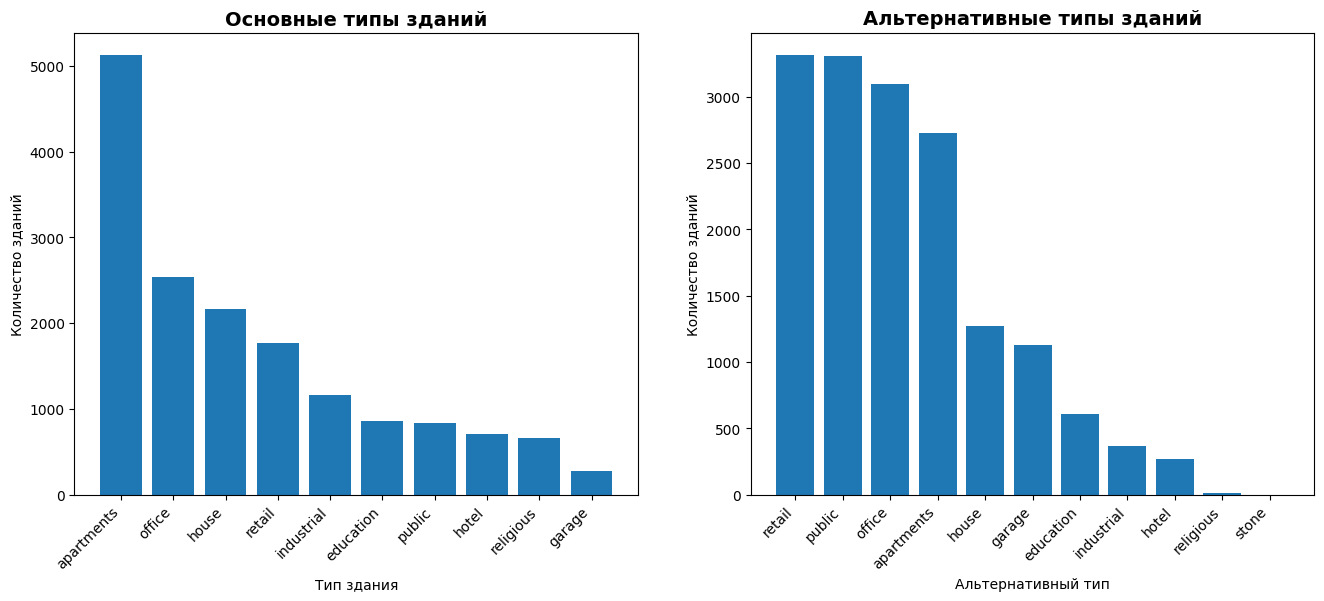

In [8]:
import matplotlib.pyplot as plt

# Распределение по типам зданий
type_cnt = df['type'].value_counts()
type_cnt_alt = df['type_alt'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(range(len(type_cnt)), type_cnt.values)
ax1.set_xticks(range(len(type_cnt)))
ax1.set_xticklabels(type_cnt.index, rotation=45, ha='right')
ax1.set_xlabel('Тип здания')
ax1.set_ylabel('Количество зданий')
ax1.set_title('Основные типы зданий', fontsize=14, fontweight='bold')

ax2.bar(range(len(type_cnt_alt)), type_cnt_alt.values)
ax2.set_xticks(range(len(type_cnt_alt)))
ax2.set_xticklabels(type_cnt_alt.index, rotation=45, ha='right')
ax2.set_xlabel('Альтернативный тип')
ax2.set_ylabel('Количество зданий')
ax2.set_title('Альтернативные типы зданий', fontsize=14, fontweight='bold')

Text(0.5, 1.0, 'Альтернативные материалы отделки')

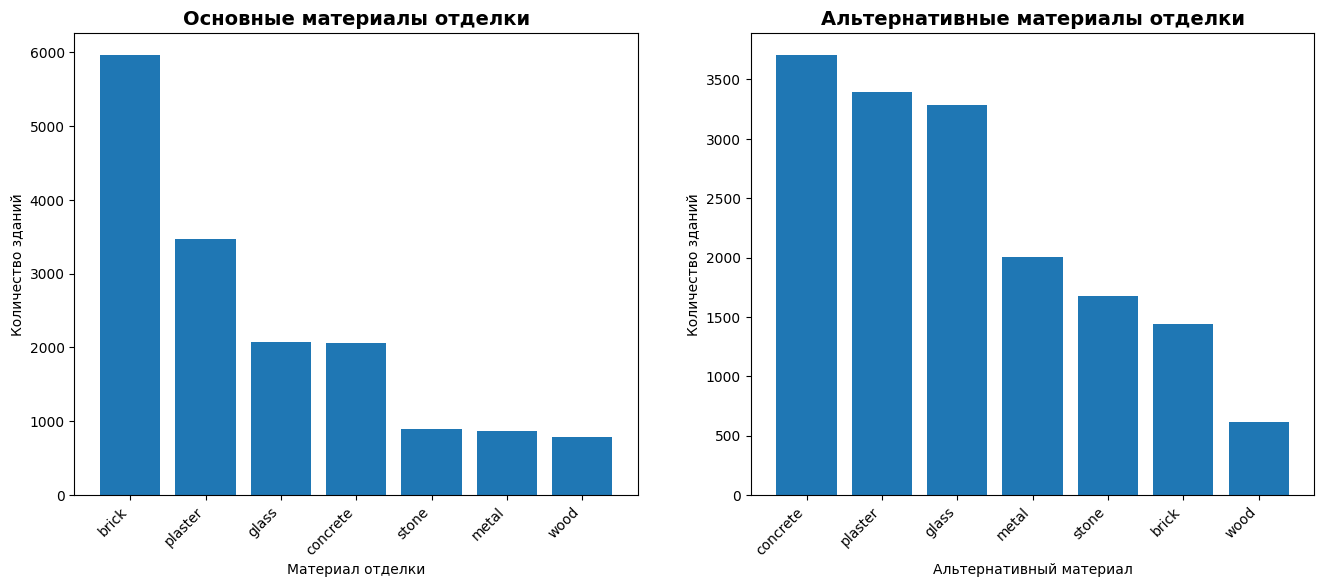

In [9]:
# Распределение по материалам наружней отделки
mat_cnt = df['surface_mat'].value_counts()
mat_cnt_alt = df['surface_mat_alt'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(range(len(mat_cnt)), mat_cnt.values)
ax1.set_xticks(range(len(mat_cnt)))
ax1.set_xticklabels(mat_cnt.index, rotation=45, ha='right')
ax1.set_xlabel('Материал отделки')
ax1.set_ylabel('Количество зданий')
ax1.set_title('Основные материалы отделки', fontsize=14, fontweight='bold')

ax2.bar(range(len(mat_cnt_alt)), mat_cnt_alt.values)
ax2.set_xticks(range(len(mat_cnt_alt)))
ax2.set_xticklabels(mat_cnt_alt.index, rotation=45, ha='right')
ax2.set_xlabel('Альтернативный материал')
ax2.set_ylabel('Количество зданий')
ax2.set_title('Альтернативные материалы отделки', fontsize=14, fontweight='bold')

In [10]:
# Посмотрю какая этажность наблюдается в датасете
df['floors'].unique()

array([  3,   6,   4,   8,  12,  16,   5,  19,  23,   7,   2,  10,   1,
        25,   9,  46,  30,  18,  20,  38,  15,  21,  14,  35,  22,  36,
        61,  58,  43,  11,  24,  32,  48, 200,  40,  55,  50,  17,  26,
        33,  31,  29, 100,  56])

**Значения 100 и 200 этажей вполне могут быть артефактами. В ближайшие дни проведу ручную проверку/разметку датасета и посмотрю фото этих зданий.**

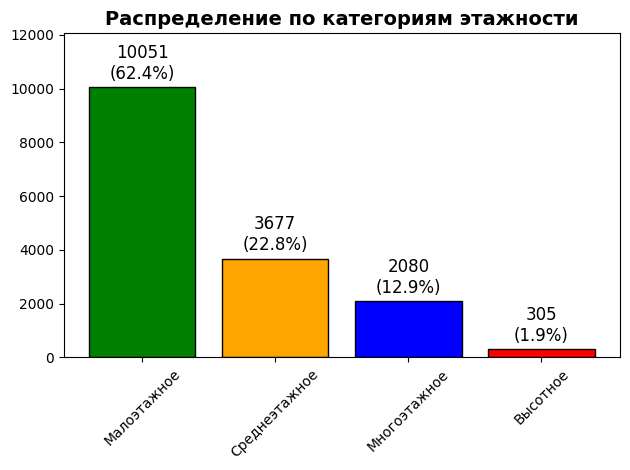

In [31]:
# Оценка категорий в соотвествии с классификации этажности в РФ
def floor_cat(floors):
    if floors <= 4:
        return 'Малоэтажное'
    elif floors > 4 and floors <= 8:
        return 'Среднеэтажное'
    elif floors > 8 and floors <= 25:
        return 'Многоэтажное'
    else:
        return 'Высотное'

df['floor_cat'] = df['floors'].apply(floor_cat)
cat_counts = df['floor_cat'].value_counts()
total = cat_counts.sum()
percentages = (cat_counts / total * 100).round(1)

colors = ['green', 'orange', 'blue', 'red']
plt.bar(cat_counts.index, cat_counts.values, color=colors, edgecolor='black')
plt.ylim(0, cat_counts.max() * 1.2)

for i, (cat, count) in enumerate(cat_counts.items()):
    plt.text(i, count + (total * 0.01), 
             f'{count}\n({percentages[cat]}%)', 
             ha='center', va='bottom', fontsize=12)

plt.title('Распределение по категориям этажности', fontsize=14, fontweight='bold')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

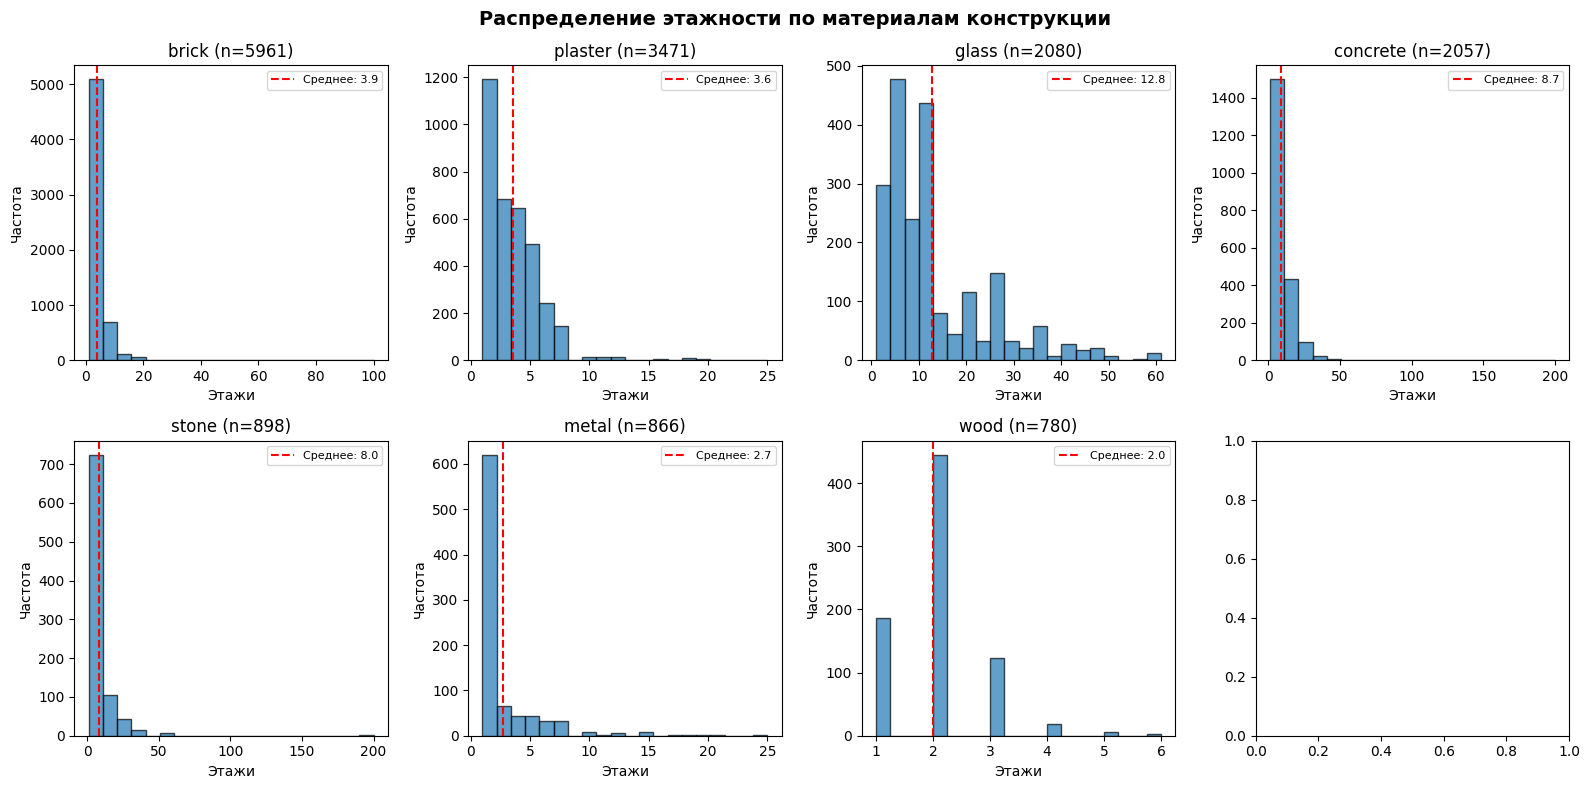

In [12]:
# Распределение этажности для разных материалов конструкции
mats = df['surface_mat'].value_counts().index

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, mat in enumerate(mats):
    subset = df[df['surface_mat'] == mat]['floors']
    axes[i].hist(subset, bins=20, edgecolor='black', alpha=0.7)
    axes[i].axvline(subset.mean(), color='red', ls='--', label=f'Среднее: {subset.mean():.1f}')
    axes[i].set_title(f'{mat} (n={len(subset)})')
    axes[i].set_xlabel('Этажи')
    axes[i].set_ylabel('Частота')
    axes[i].legend(fontsize=8)

plt.suptitle('Распределение этажности по материалам конструкции', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

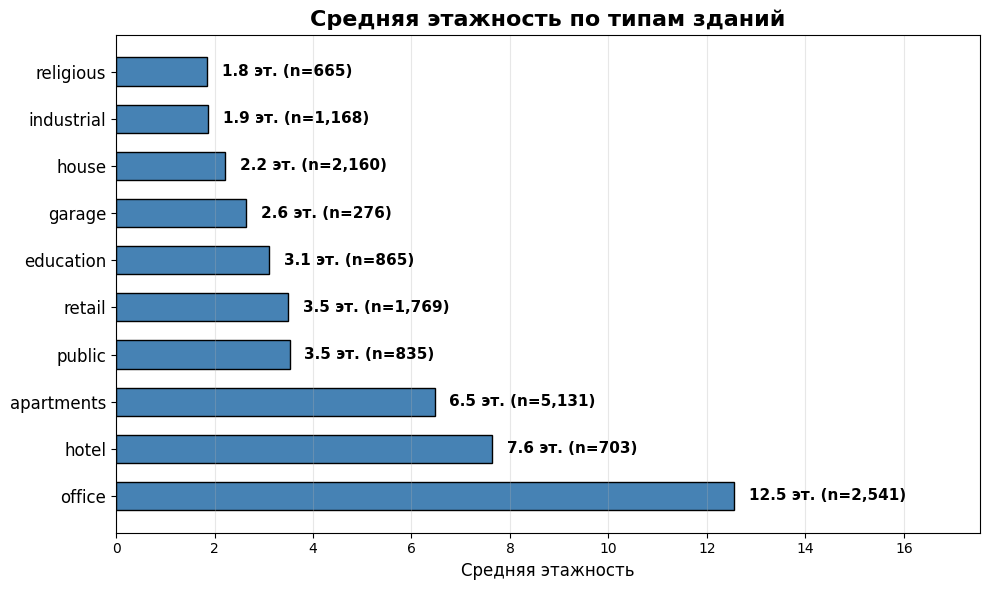

In [32]:
# Средняя этажность в зависимости от типа здания
mean_floors = df.groupby('type')['floors'].agg(['mean', 'count']).sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(range(len(mean_floors)), mean_floors['mean'].values, 
               color='steelblue', edgecolor='black', height=0.6)

for i, (val, cnt) in enumerate(zip(mean_floors['mean'].values, mean_floors['count'].values)):
    ax.text(val + 0.3, i, f'{val:.1f} эт. (n={cnt:,})', 
            va='center', fontsize=11, fontweight='bold')

ax.set_yticks(range(len(mean_floors)))
ax.set_yticklabels(mean_floors.index, fontsize=12)
ax.set_xlabel('Средняя этажность', fontsize=12)
ax.set_title('Средняя этажность по типам зданий', fontsize=16, fontweight='bold')
ax.set_xlim(0, mean_floors['mean'].max() + 5)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [14]:
# Средний год постройки по материалу здания
print("Материалы отделки по году постройки")
mean_age_mat = df.groupby('surface_mat')['age'].agg(['mean', 'count']).sort_values('mean')
for mat, row in mean_age_mat.iterrows():
    print(f"- {mat}, средний год постройки: {row['mean']:.0f}, построек: {int(row['count'])};")

Материалы отделки по году постройки
- stone, средний год постройки: 1915, построек: 898;
- brick, средний год постройки: 1932, построек: 5961;
- plaster, средний год постройки: 1946, построек: 3471;
- wood, средний год постройки: 1953, построек: 780;
- concrete, средний год постройки: 1979, построек: 2057;
- metal, средний год постройки: 1993, построек: 866;
- glass, средний год постройки: 1996, построек: 2080;


Text(0.5, 1.0, 'Форматы изображений')

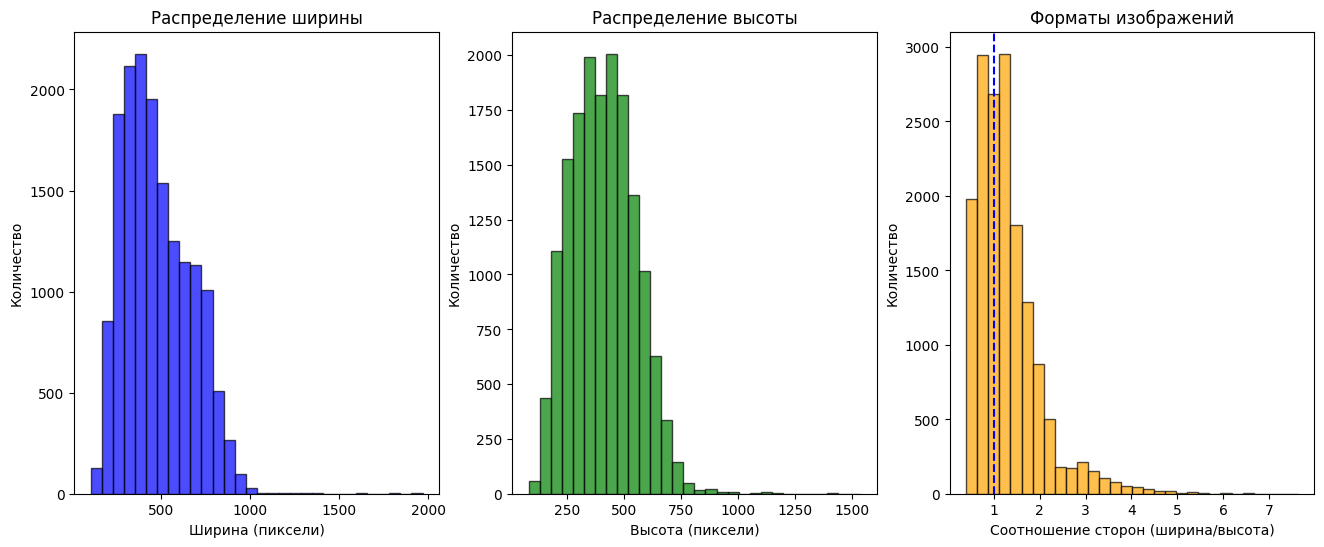

In [15]:
# Параметры размера самих изображений
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

ax1.hist(df['img_width'], bins=30, edgecolor='black', alpha=0.7, color='blue')
ax1.set_xlabel('Ширина (пиксели)')
ax1.set_ylabel('Количество')
ax1.set_title('Распределение ширины')

ax2.hist(df['img_height'], bins=30, edgecolor='black', alpha=0.7, color='green')
ax2.set_xlabel('Высота (пиксели)')
ax2.set_ylabel('Количество')
ax2.set_title('Распределение высоты')

ax3.hist(df['wh_ratio'], bins=30, edgecolor='black', alpha=0.7, color='orange')
ax3.axvline(1.0, color='blue', ls='--')
ax3.set_xlabel('Соотношение сторон (ширина/высота)')
ax3.set_ylabel('Количество')
ax3.set_title('Форматы изображений')

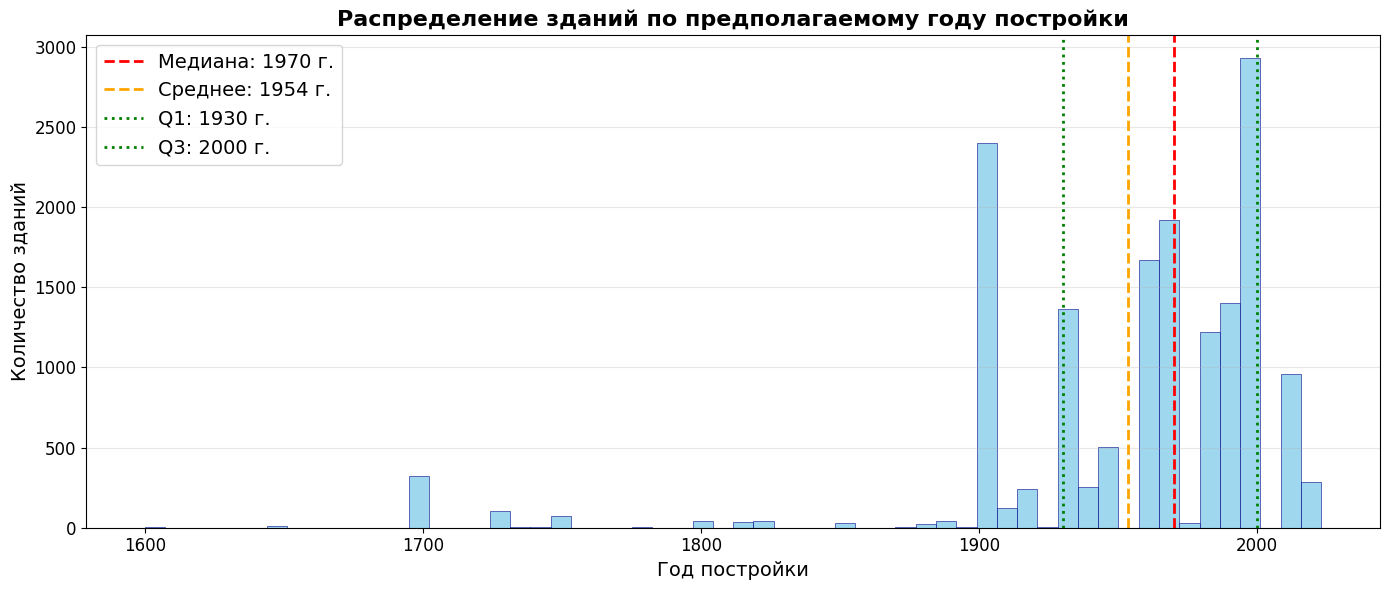

In [49]:
# Беру год после 1600 для улучшения читаемости
df_filtered = df[df['age'] >= 1600]

fig, ax = plt.subplots(figsize=(14, 6))

n_bins = min(80, df_filtered['age'].nunique())
n, bins, patches = ax.hist(
    df_filtered['age'],
    bins=n_bins,
    color='skyblue',
    edgecolor='darkblue',
    alpha=0.8,
    linewidth=0.5
)

# Статистика
median_val = df_filtered['age'].median()
mean_val = df_filtered['age'].mean()
q1_val = df_filtered['age'].quantile(0.25)
q3_val = df_filtered['age'].quantile(0.75)

ax.axvline(median_val, color='red', linestyle='--', linewidth=2, 
           label=f'Медиана: {median_val:.0f} г.')
ax.axvline(mean_val, color='orange', linestyle='--', linewidth=2, 
           label=f'Среднее: {mean_val:.0f} г.')
ax.axvline(q1_val, color='green', linestyle=':', linewidth=2, 
           label=f'Q1: {q1_val:.0f} г.')
ax.axvline(q3_val, color='green', linestyle=':', linewidth=2, 
           label=f'Q3: {q3_val:.0f} г.')

ax.set_xlabel('Год постройки', fontsize=14)
ax.set_ylabel('Количество зданий', fontsize=14)
ax.set_title(
    'Распределение зданий по предполагаемому году постройки',
    fontsize=16,
    fontweight='bold'
)
ax.legend(loc='upper left', fontsize=14)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

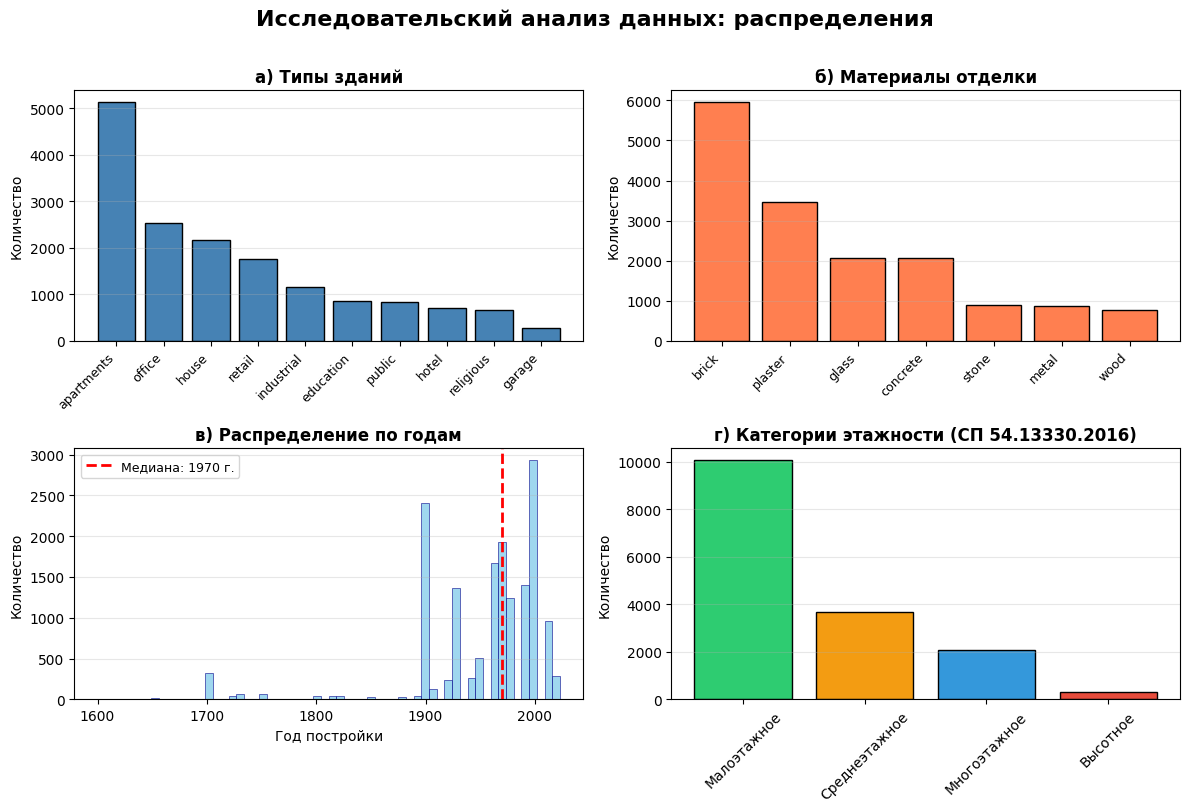

In [17]:
# Графики для презентации
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Типы зданий
type_cnt = df['type'].value_counts()
axes[0, 0].bar(range(len(type_cnt)), type_cnt.values, color='steelblue', edgecolor='black')
axes[0, 0].set_xticks(range(len(type_cnt)))
axes[0, 0].set_xticklabels(type_cnt.index, rotation=45, ha='right', fontsize=9)
axes[0, 0].set_ylabel('Количество')
axes[0, 0].set_title('а) Типы зданий', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Материалы отделки
mat_cnt = df['surface_mat'].value_counts()
axes[0, 1].bar(range(len(mat_cnt)), mat_cnt.values, color='coral', edgecolor='black')
axes[0, 1].set_xticks(range(len(mat_cnt)))
axes[0, 1].set_xticklabels(mat_cnt.index, rotation=45, ha='right', fontsize=9)
axes[0, 1].set_ylabel('Количество')
axes[0, 1].set_title('б) Материалы отделки', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Годы постройки
axes[1, 0].hist(df_filtered['age'], bins=60, color='skyblue', edgecolor='darkblue', alpha=0.8, linewidth=0.5)
axes[1, 0].axvline(df_filtered['age'].median(), color='red', ls='--', linewidth=2, 
                   label=f"Медиана: {df_filtered['age'].median():.0f} г.")
axes[1, 0].set_xlabel('Год постройки')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].set_title('в) Распределение по годам', fontweight='bold')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(axis='y', alpha=0.3)

# Категории этажности
cat_order = ['Малоэтажное', 'Среднеэтажное', 'Многоэтажное', 'Высотное']
cat_counts = df['floor_cat'].value_counts().reindex(cat_order)
colors = ['#2ecc71', '#f39c12', '#3498db', '#e74c3c']
axes[1, 1].bar(cat_counts.index, cat_counts.values, color=colors, edgecolor='black')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].set_title('г) Категории этажности (СП 54.13330.2016)', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.suptitle('Исследовательский анализ данных: распределения', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()